<div class='alert alert-block alert-info"'>
<h1> Comparaison dans le modèle linéaire à effet mixtes avec Ollier-2017 :</h1>

<h4> cf, toy example p14 : Stochastic Proximal Gradient Algorithms
for Penalized Mixed Models </h4>

#### LMEM Specification

## Ollier et al

Ollier et al présente le modèle suivant dans leur article :

Pour $k\in\{1,...,N\}, j \in\{1, ..., J\}$ avec $N = 40, J = 8$ et $D = 300$

$$Y_{k,j} = Z_0^{(k)}+Z_1^{(k)} \times t_{k,j} + \epsilon ~;~\epsilon\sim \mathcal N(0,1)$$

Avec $Z^{(k)} \sim \mathcal N(X_k\theta; I_2)$ et $t_{k,.} = [0.25,4,6,8,10,12,14,16]$

$$X_k = \left[\begin{array}{cccccc}
        1 & X_{k1} & \dots & X_{kD} & 0 & \dots &\dots & 0 
    \\  0 & \dots & \dots & 0  & 1 & X_{k1} & \dots & X_{kD}
    \end{array}\right]$$

Le choix lors de leur étude de simulation est le suivant : 

$X_k\sim\mathcal N_D (0,\Gamma)$ avec $\Gamma_{r,r'} = 0.5^{|r-r'|}$

Ils font de la sélection sur $\theta\in\mathbb R^{2+2\times(D+1)}$ sauf sur les composantes liées aux intercepts $\theta_2$ et $\theta_{D+2}$.

Ils choisissent aléatoirement 6 composantes dans $\{2,D+1\}$ puis dans $\{D+3,2D+2\}$ pour être tiré dans $\mathcal U([0.5,1.5])$ le reste des composantes est fixé à zéro sauf  $\theta_2 ^* =\theta_{D+2}^*  = 1$

Ils simulent un unique data set puis performent 100 résolutions de leur méthode et des méthodes avec qui ils se comparent.

## Variation du modèle pour l'implémentation

Afin de coller aux contraintes dues à l'implémentation du package, je propose le modèle suivant qui me semble être qu'une ré-écriture du modèle linéaire proposé ce dessus. La différence réside dans la définition d'intercept séparément du vecteur des paramètres où l'on souhaite faire de la sélection.


Pour $k\in\{1,...,N\}, j \in\{1, ..., J\}$ avec $N = 40, J = 8$ et $D = 300$

$$Y_{k,j} = Z_1^{(k)}+Z_2^{(k)} \times t_{k,j} + \epsilon ~;~\epsilon\sim \mathcal N(0,1)$$

Avec $Z^{(k)}_1 \sim \mathcal N(\mu_1 + X_k\theta_1; 1)$ et $Z^{(k)}_2 \sim \mathcal N(\mu_2 + X_k\theta_2; 1)$ et $t_{k,.} = [0.25,4,6,8,10,12,14,16]$

$$X_k = \left[X_{k1} ~ \dots ~ X_{kD}\right]$$

Le choix lors de leur étude de simulation est le suivant : 

$X_k\sim\mathcal N_D (0,\Gamma)$ avec $\Gamma_{r,r'} = 0.5^{|r-r'|}$


In [213]:
import functools
from jax import jit
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc

import sdg4varselect.plot as sdgplt

from sdg4varselect.models import (
    AbstractMixedEffectsModel,
    AbstractHDModel,
)


def cov_multivariate(prngkey, shape):
    x = jnp.arange(0, shape[1])
    cov_matrix = 0.5 ** jnp.abs(x[:, None] - x[None, :])

    return jrd.multivariate_normal(
        prngkey, jnp.zeros(shape=shape[1]), cov=cov_matrix, shape=(shape[0],)
    )


class LinearMixedEffectsModel(AbstractMixedEffectsModel, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P=1, **kwargs):
        AbstractMixedEffectsModel.__init__(
            self,
            N=N,
            J=J,
            me_name=["Z1", "Z2"],
            **kwargs,
        )
        AbstractHDModel.__init__(self, P=P)

        self.init()

    @property
    def name(self):
        """return a str called name, based on the parameter of the model"""
        return f"LinearMEM_N{self.N}_J{self.J}_P{self.P}"

    def init(self):
        """here you define the parametrization of the model
        and don't forget to call the mother init function at the end"""
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.Real(scale=1),
                mu2=pc.Real(scale=1),
            ),
            cov_latent=pc.MatrixDiagPosDef(
                dim=2,
            ),
            var_residual=pc.RealPositive(scale=1),
            theta1=pc.Real(scale=1, shape=(self.P,)),
            theta2=pc.Real(scale=1, shape=(self.P,)),
        )
        AbstractHDModel.init_dim(self)

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(
        self,
        params,
        times: jnp.ndarray,  # shape = (J,) [None, :]
        Z1: jnp.ndarray,  # shape = (N,) [:,None]
        Z2: jnp.ndarray,  # shape = (N,) [:,None]
        cov: jnp.ndarray,  # shape = (N,p)
        **kwargs,
    ) -> jnp.ndarray:  # shape = (N,J)
        """Linear model"""
        Z1bis = Z1 + cov @ params.theta1
        Z2bis = Z2 + cov @ params.theta2

        out = Z1bis[:, None] + Z2bis[:, None] * times
        assert out.shape == times.shape
        return out

    # ============================================================== #

    def sample(
        self,
        params_star,
        prngkey,
        **kwargs,
    ):
        """Sample one data set for the model"""

        (
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.array([0.25, 4, 6, 8, 10, 12, 14, 16])
        time = jnp.repeat(time[None, :], self.N, axis=0)
        cov = cov_multivariate(prngkey_cov, shape=(self.N, self.P))

        obs, sim = AbstractMixedEffectsModel.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov=cov
        )

        return {"mem_obs_time": time, "cov": cov} | obs, sim

In [214]:
myModel = LinearMixedEffectsModel(N=100, J=8, P=20)

number_non_zero_component = 6

supp1_star = jrd.choice(
    jrd.PRNGKey(0),
    jnp.arange(0, myModel.P),
    shape=(number_non_zero_component,),
    replace=False,
).sort()
theta_rdm = jrd.uniform(jrd.PRNGKey(1), shape=(myModel.P,), minval=0.5, maxval=1.5)
theta1_star = jnp.zeros(shape=theta_rdm.shape).at[supp1_star].set(theta_rdm[supp1_star])

supp2_star = jrd.choice(
    jrd.PRNGKey(2),
    jnp.arange(0, myModel.P),
    shape=(number_non_zero_component,),
    replace=False,
).sort()
theta_rdm = jrd.uniform(jrd.PRNGKey(3), shape=(myModel.P,), minval=0.5, maxval=1.5)
theta2_star = jnp.zeros(shape=theta_rdm.shape).at[supp2_star].set(theta_rdm[supp2_star])


p_star = myModel.new_params(
    mean_latent={"mu1": 1, "mu2": 1},
    cov_latent=jnp.diag(jnp.ones(2)),
    var_residual=1,
    theta1=theta1_star,
    theta2=theta2_star,
)

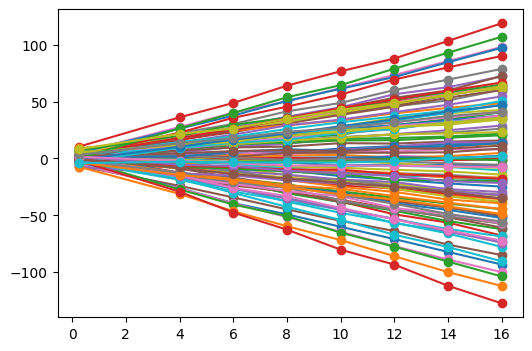

In [215]:
myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

fig = sdgplt.figure(4, 6)
ax = fig.add_subplot(1, 1, 1)
_ = ax.plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

In [216]:
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.algo import SPGD_FIM, get_gdfim_settings
import sdg4varselect.algo.preconditioner as sdgpreconditioner

algo_settings = get_gdfim_settings(preheating=1000, heating=1500, learning_rate=1e-3)

preconditioner = sdgpreconditioner.Fisher(list(algo_settings)[1:])
# preconditioner = sdgpreconditioner.AdaGrad(1e-3)

In [217]:
freezed_components = jnp.array(
    [False, False, True, True, True]
    + [False] * myModel.P
    + [False] * 2
    + [False]
    + [False] * (myModel.P - 3)
)
freezed_components = jnp.array(
    [False, False, True, True, True] + [False] * myModel.P + [True] * myModel.P
)
# freezed_components = jnp.array([False, True, True, True, True] + [False] + [True])


def one_estim(prngkey, model, data, lbd=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))
    theta0 = jnp.where(
        freezed_components, myModel.parametrization.params_to_reals1d(p_star), theta0
    )

    algo = SPGD_FIM(
        prngkey_estim, 5000, algo_settings, preconditioner, lbd=lbd, alpha=1.0
    )
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"Z1": 1, "Z2": 1})

    for var_lat in algo.latent_variables.values():
        var_lat.adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(
        model,
        data,
        theta0,
        freezed_components=freezed_components,
        ntry=5,
        partial_fit=False,
        save_all=save_all,
    )

    # sdgplt.plot_mcmc(algo.latent_variables)
    # print(algo._heating)
    return res


multi_res = MultiRunRes(
    [
        one_estim(jrd.PRNGKey(key), myModel, myobs, lbd=None, save_all=True)
        for key in range(10)
    ]
)

In [218]:
from sdg4varselect.outputs import TestResults

results = TestResults(
    [MultiRunRes([MultiRunRes([r]) for r in multi_res])],
    test_config=[{"name": f"0"}],
)

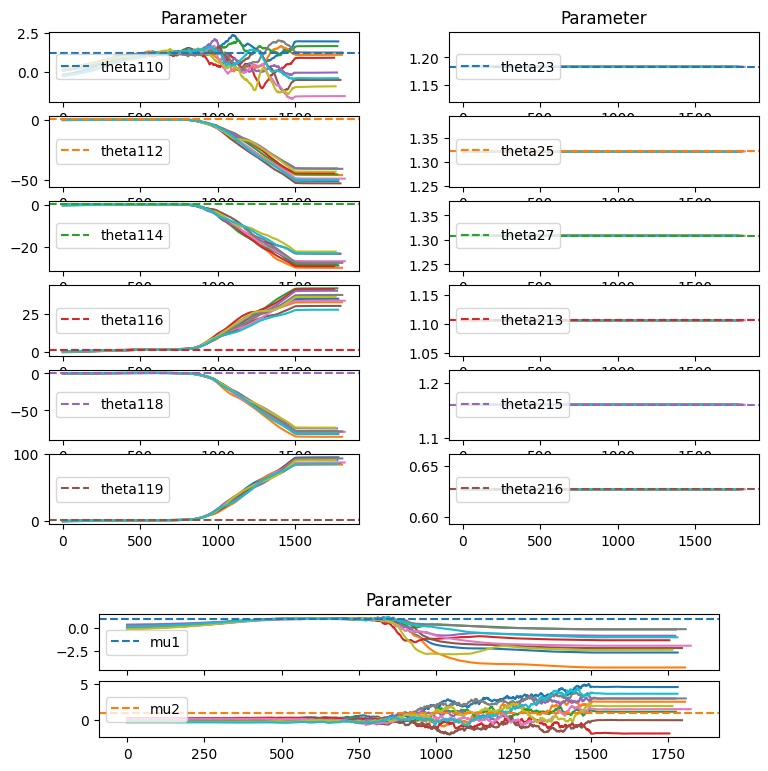

In [219]:
fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 1, wspace=0.07, height_ratios=[4, 1])
subfigs2 = subfigs[0].subfigures(1, 2, wspace=0.07)

_ = sdgplt.plot_theta(
    multi_res,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    id_to_plot=[0, 1],
    log_scale=True,
    fig=subfigs[1],
)

_ = sdgplt.plot_theta(
    multi_res,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    id_to_plot=7 + supp1_star,
    log_scale=False,
    fig=subfigs2[0],
)
_ = sdgplt.plot_theta(
    multi_res,
    params_star=myModel.hstack_params(p_star),
    params_names=myModel.params_names,
    id_to_plot=7 + myModel.P + supp2_star,
    log_scale=False,
    fig=subfigs2[1],
)

In [220]:
supp2_star

Array([ 2,  4,  6, 12, 14, 15], dtype=int64)

In [221]:
theta2_star

Array([0.        , 0.        , 1.18259391, 0.        , 1.32220107,
       0.        , 1.30841321, 0.        , 0.        , 0.        ,
       0.        , 0.        , 1.10602558, 0.        , 1.16037026,
       0.62718827, 0.        , 0.        , 0.        , 0.        ],      dtype=float64)

In [222]:
multi_res.last_theta[0, 17:]

Array([-27.38665163, -50.51755926,  24.63836031, -28.66708797,
       -60.69842298,  35.36727223,  20.25344464, -81.82503342,
        95.27216437,   1.54515025,   0.        ,   0.        ,
         1.18259391,   0.        ,   1.32220107,   0.        ,
         1.30841321,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   1.10602558,   0.        ,
         1.16037026,   0.62718827,   0.        ,   0.        ,
         0.        ,   0.        ], dtype=float64)

In [223]:
(myobs["cov"] @ theta2_star)[0] + mysim["Z2"][0]

Array(-0.2844786, dtype=float64)

In [224]:
(myobs["cov"] @ multi_res.last_theta[0, 17:])[0] + mysim["Z2"][0]

TypeError: dot_general requires contracting dimensions to have the same shape, got (20,) and (30,).

In [ ]:
results[0].sort()

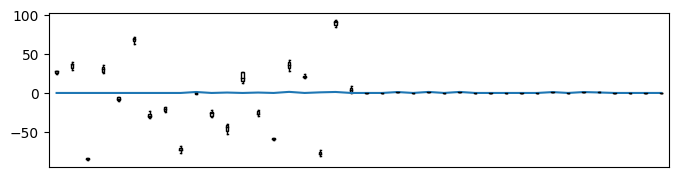

In [225]:
theta = jnp.array(results.last_theta)[0, len(results) - 8 :, 1, 7:]

params_star_HD = jnp.concatenate([p_star.theta1, p_star.theta2])

ax = sdgplt.get_ax(2, 8)
_ = sdgplt.myBoxplot(
    ax=ax,
    x=theta.T,
)
ax.plot(params_star_HD)  # , "bs", label="true value")

In [ ]:
jnp.concatenate([p_star.theta1, p_star.theta2])

Array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 1.4697712 , 0.68764287, 1.38873853,
       0.        , 0.91987128, 0.71385938, 0.        , 1.38779216],      dtype=float64)

In [ ]:
[p_star.theta1, p_star.theta2]

[Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float64),
 Array([0.        , 0.        , 1.4697712 , 0.68764287, 1.38873853,
        0.        , 0.91987128, 0.71385938, 0.        , 1.38779216],      dtype=float64)]